# CTA Assault Data - Seasonal Trends & ML Forecasting

## Objective
This notebook demonstrates how to:
1. Load and explore CTA assault incident data
2. Perform seasonal decomposition to understand patterns
3. Build time series forecasting models (Prophet)
4. Generate predictions for next 3-6 months
5. Create visualizations for PDF reports

## Approach (Hybrid Model)
- **Location-specific forecasts**: Predict assaults at specific stops/locations
- **System-wide context**: Compare location trends vs CTA-wide trends
- **Seasonal patterns**: Identify monthly, weekly, hourly patterns

---

## 1. Setup & Dependencies

Install required libraries (run once):
```bash
pip install pandas numpy matplotlib seaborn prophet statsmodels scikit-learn
```

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print(f"   - pandas: {pd.__version__}")
print(f"   - numpy: {np.__version__}")

✅ Libraries imported successfully!
   - pandas: 2.3.3
   - numpy: 2.2.6


---
## 2. Load CTA Assault Data

We'll load the cleaned CSV file containing 3,752 assault incidents with:
- **Event Date**: Format "YYYY Month DD" (e.g., "2025 April 24")
- **Event Time**: Format "H:MM:SS am/pm"
- **Location**: Latitude, Longitude, Address
- **Event Details**: Type, Category, Severity, Injuries

In [2]:
# Load the CSV data
CSV_PATH = r"C:\Users\azeez\PROJECTS\CTA-MAP-ASSAULT\Cleaned_CTA_Bus_Data.csv"

print("📂 Loading CTA assault data...")
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"✅ Data loaded successfully!")
print(f"   Total incidents: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
df.head()

📂 Loading CTA assault data...
✅ Data loaded successfully!
   Total incidents: 3,749
   Columns: 122
   Memory usage: 12.98 MB


,NTD ID,Agency,Primary UZA UACE Code,Rail/Bus/Ferry,Mode Name,Mode,TOS,Fixed Route Flag,Year,Event Description,...,Occupant of Other Vehicle Injuries,Occupant of Other Vehicle Serious Injuries,Other Injuries,Other Serious Injuries,Suicide Injuries,Suicide Serious Injuries,Trespasser Inuries (Subtotal),Trespasser Serious Injuries (Subtotal),Total Serious Injuries,Person List
0,50066,chicago transit authority,16264,bus,bus,mb,do,True,2025,an employee was transported to the hospital af...,...,0,0,0,0,0,0,0,0,0,i operator inside adult (19 to 60) m
1,50066,chicago transit authority,16264,bus,bus,mb,do,True,2025,a male passenger was attacked aboard the bus a...,...,0,0,0,0,0,0,0,0,0,i passenger adult (19 to 60) m
2,50066,chicago transit authority,16264,bus,bus,mb,do,True,2025,"on april 7 , 2025 , bus < redacted > was stati...",...,0,0,0,0,0,0,0,0,0,i passenger adult (19 to 60) m ; i passen...
3,50066,chicago transit authority,16264,bus,bus,mb,do,True,2025,"on april 4 , 2025 , bus < redacted > was stati...",...,0,0,0,0,0,0,0,0,0,i passenger adult (19 to 60) f ; i operat...
4,50066,chicago transit authority,16264,bus,bus,mb,do,True,2025,the male passenger was attacked and robbed of ...,...,0,0,0,0,0,0,0,0,0,i passenger adult (19 to 60) m


---
## 3. Data Preprocessing & Feature Engineering

### Tasks:
1. Parse dates from "YYYY Month DD" format to datetime
2. Parse times to extract hour-of-day (0-23)
3. Extract temporal features: year, month, day_of_week, hour
4. Handle missing values

In [3]:
# Function to parse CTA date format: "2025 April 24"
def parse_cta_date(date_str):
    """Parse CTA date format 'YYYY Month DD' to datetime."""
    if pd.isna(date_str) or not date_str:
        return pd.NaT
    try:
        return pd.to_datetime(date_str, format='%Y %B %d')
    except:
        try:
            # Fallback: try different format
            return pd.to_datetime(date_str)
        except:
            return pd.NaT

# Function to parse time and extract hour
def parse_cta_time(time_str):
    """Parse CTA time format 'H:MM:SS am/pm' to hour (0-23)."""
    if pd.isna(time_str) or not time_str:
        return None
    try:
        # Parse time
        dt = pd.to_datetime(time_str, format='%I:%M:%S %p')
        return dt.hour
    except:
        return None

print("🔄 Processing dates and times...")

# Parse dates
df['parsed_date'] = df['Event Date'].apply(parse_cta_date)

# Parse times
df['hour'] = df['Event Time'].apply(parse_cta_time)

# Extract temporal features
df['year'] = df['parsed_date'].dt.year
df['month'] = df['parsed_date'].dt.month
df['day_of_week'] = df['parsed_date'].dt.dayofweek  # Monday=0, Sunday=6
df['day_name'] = df['parsed_date'].dt.day_name()
df['month_name'] = df['parsed_date'].dt.month_name()

# Create year-month for aggregation
df['year_month'] = df['parsed_date'].dt.to_period('M')

# Check for missing dates
valid_dates = df['parsed_date'].notna().sum()
total_records = len(df)

print(f"✅ Preprocessing complete!")
print(f"   Valid dates: {valid_dates:,} / {total_records:,} ({valid_dates/total_records*100:.1f}%)")
print(f"   Date range: {df['parsed_date'].min()} to {df['parsed_date'].max()}")
print(f"   Total months: {df['year_month'].nunique()}")

# Show sample
df[['Event Date', 'parsed_date', 'Event Time', 'hour', 'month_name', 'day_name']].head(10)

🔄 Processing dates and times...
✅ Preprocessing complete!
   Valid dates: 3,749 / 3,749 (100.0%)
   Date range: 2014-01-02 00:00:00 to 2025-04-28 00:00:00
   Total months: 136


,Event Date,parsed_date,Event Time,hour,month_name,day_name
0,2025 april 24,2025-04-24,7:43:00 pm,19,April,Thursday
1,2025 april 19,2025-04-19,10:40:00 am,10,April,Saturday
2,2025 april 07,2025-04-07,12:25:00 am,0,April,Monday
3,2025 april 04,2025-04-04,4:26:00 pm,16,April,Friday
4,2025 february 26,2025-02-26,4:06:00 pm,16,February,Wednesday
5,2025 january 16,2025-01-16,11:46:00 pm,23,January,Thursday
6,2025 january 14,2025-01-14,3:46:00 pm,15,January,Tuesday
7,2024 november 22,2024-11-22,2:09:00 pm,14,November,Friday
8,2016 october 08,2016-10-08,2:40:00 pm,14,October,Saturday
9,2024 october 25,2024-10-25,5:12:00 pm,17,October,Friday


---
## 4. Exploratory Data Analysis (EDA)

### Understand the data distribution:
- Event types and categories
- Temporal distribution (years, months, hours)
- Geographic distribution

In [4]:
# Event type distribution
print("📊 EVENT TYPE DISTRIBUTION")
print("="*50)
event_counts = df['Event Type'].value_counts().head(10)
print(event_counts)
print()

# Event type group (category) distribution
print("📊 EVENT CATEGORY DISTRIBUTION")
print("="*50)
category_counts = df['Event Type Group'].value_counts()
print(category_counts)
print()

# Yearly distribution
print("📊 YEARLY DISTRIBUTION")
print("="*50)
yearly_counts = df['year'].value_counts().sort_index()
print(yearly_counts)
print()

# Monthly aggregates (total count per month)
monthly_counts = df.groupby('year_month').size()
print(f"Monthly incident counts (sample):")
print(monthly_counts.head(12))

📊 EVENT TYPE DISTRIBUTION
Event Type
non-rail collision                                2636
assault                                            693
assault not against transit worker                 142
physical assault on an operator                    117
other                                               94
robbery                                             17
non rail fire                                       13
vandalism                                            9
chemical / biological / nuclear / radiological       8
physical assault on other transit worker             6
Name: count, dtype: int64

📊 EVENT CATEGORY DISTRIBUTION
Event Type Group
collision     2640
assault        962
other           67
security        66
fire            13
derailment       1
Name: count, dtype: int64

📊 YEARLY DISTRIBUTION
year
2014    301
2015    355
2016    351
2017    339
2018    298
2019    351
2020    319
2021    272
2022    279
2023    353
2024    401
2025    130
Name: count, dtype: int64



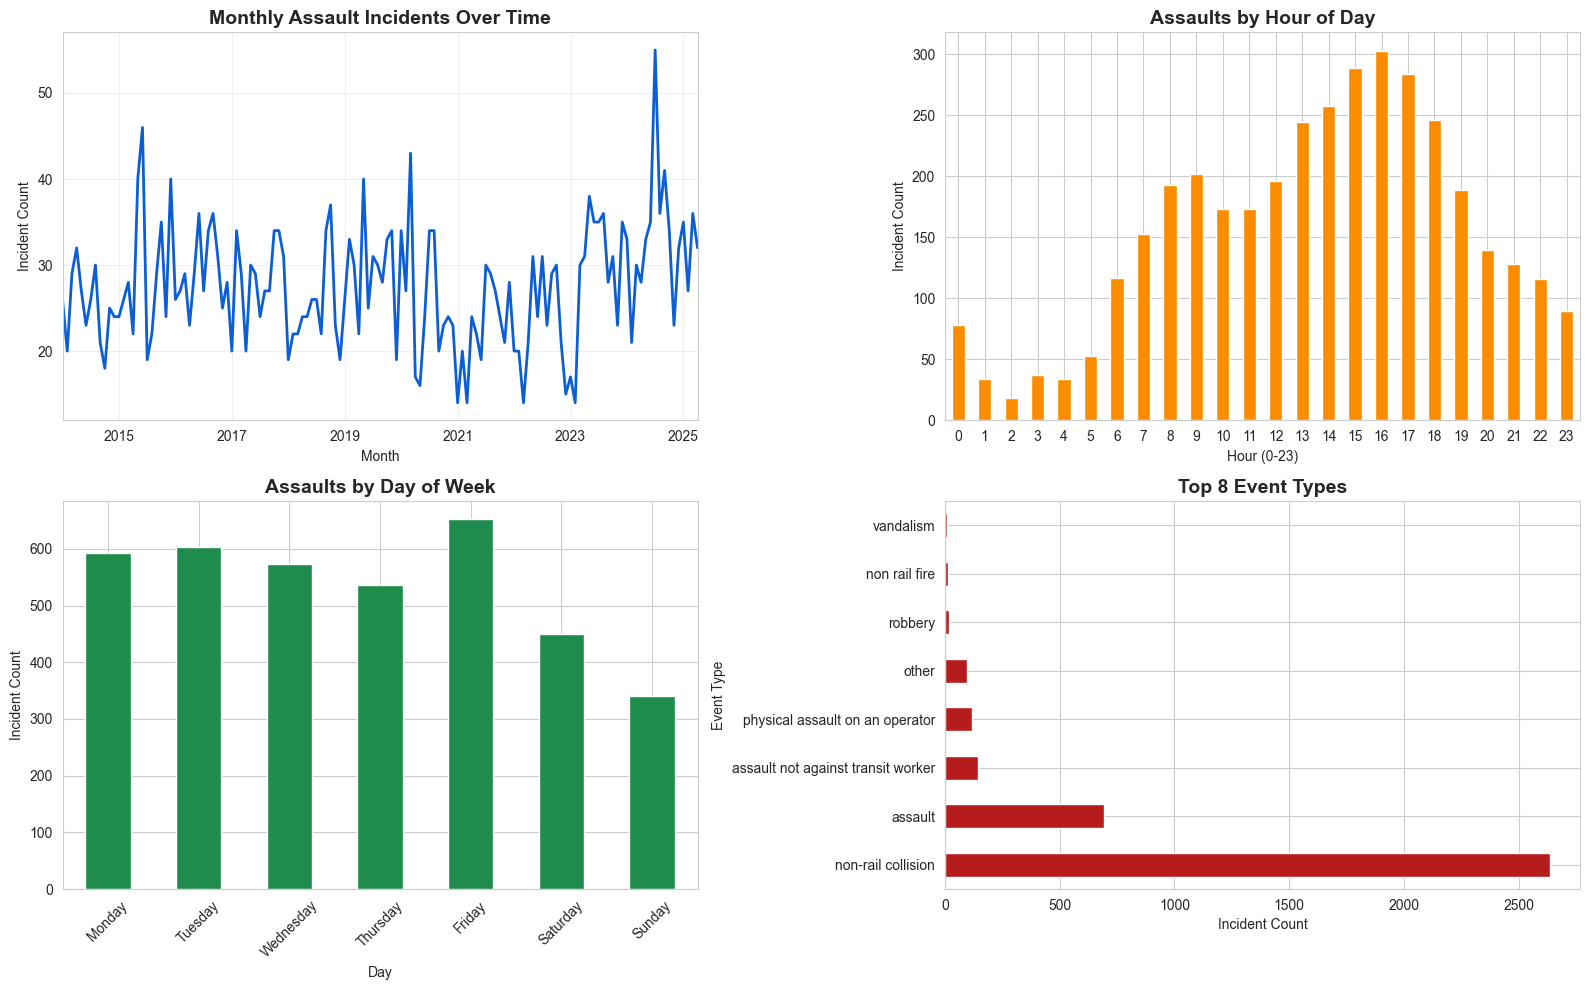


✅ Basic EDA complete! Now let's dive into seasonal decomposition and forecasting.


In [5]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Monthly trend
monthly_data = df.groupby('year_month').size()
monthly_data.plot(ax=axes[0, 0], color='#0c5ed7', linewidth=2)
axes[0, 0].set_title('Monthly Assault Incidents Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Incident Count')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Hourly distribution
hourly_data = df['hour'].value_counts().sort_index()
hourly_data.plot(kind='bar', ax=axes[0, 1], color='#fb8c00')
axes[0, 1].set_title('Assaults by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Hour (0-23)')
axes[0, 1].set_ylabel('Incident Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot 3: Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = df['day_name'].value_counts().reindex(day_order)
day_data.plot(kind='bar', ax=axes[1, 0], color='#1f8b4c')
axes[1, 0].set_title('Assaults by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Incident Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Event type breakdown
top_events = df['Event Type'].value_counts().head(8)
top_events.plot(kind='barh', ax=axes[1, 1], color='#b71c1c')
axes[1, 1].set_title('Top 8 Event Types', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Incident Count')

plt.tight_layout()
plt.show()

print("\n✅ Basic EDA complete! Now let's dive into seasonal decomposition and forecasting.")

---
## 5. Helper Functions: Location & Event Filtering

These functions allow us to:
1. Filter assaults by location (latitude/longitude + radius)
2. Filter assaults by event type or category
3. Calculate distance between points (haversine formula)

In [6]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance in kilometers between two lat/lon points using Haversine formula.
    """
    R = 6371  # Earth's radius in km
    
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)
    
    a = np.sin(delta_lat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return R * c

def filter_by_location(df, lat, lon, radius_km):
    """
    Filter dataframe to only include incidents within radius_km of (lat, lon).
    
    Returns:
        Filtered dataframe
    """
    # Calculate distance for each incident
    df_copy = df.copy()
    df_copy['distance_km'] = df_copy.apply(
        lambda row: haversine_distance(lat, lon, row['Latitude'], row['Longitude'])
        if pd.notna(row['Latitude']) and pd.notna(row['Longitude'])
        else np.inf,
        axis=1
    )
    
    # Filter within radius
    filtered = df_copy[df_copy['distance_km'] <= radius_km]
    
    return filtered

def filter_by_event_type(df, event_type=None, event_group=None):
    """
    Filter dataframe by event type or event group (category).
    
    Returns:
        Filtered dataframe
    """
    df_filtered = df.copy()
    
    if event_type:
        df_filtered = df_filtered[df_filtered['Event Type'] == event_type]
    
    if event_group:
        df_filtered = df_filtered[df_filtered['Event Type Group'] == event_group]
    
    return df_filtered

print("✅ Helper functions defined!")
print("   - haversine_distance(): Calculate distance between two points")
print("   - filter_by_location(): Filter assaults by lat/lon + radius")
print("   - filter_by_event_type(): Filter assaults by type/category")

✅ Helper functions defined!
   - haversine_distance(): Calculate distance between two points
   - filter_by_location(): Filter assaults by lat/lon + radius
   - filter_by_event_type(): Filter assaults by type/category


---
## 6. Seasonal Decomposition Analysis

**Purpose**: Break down time series into 3 components:
1. **Trend**: Long-term increase/decrease
2. **Seasonal**: Repeating patterns (monthly, yearly)
3. **Residual**: Random noise

This helps us understand:
- Is there an overall upward/downward trend?
- Are there seasonal spikes (summer, winter, weekends)?
- How predictable is the data?

📊 Seasonal Decomposition: CTA System-Wide
   Data points: 136 months
   Date range: 2014-01-01 00:00:00 to 2025-04-01 00:00:00
   Mean monthly incidents: 27.6



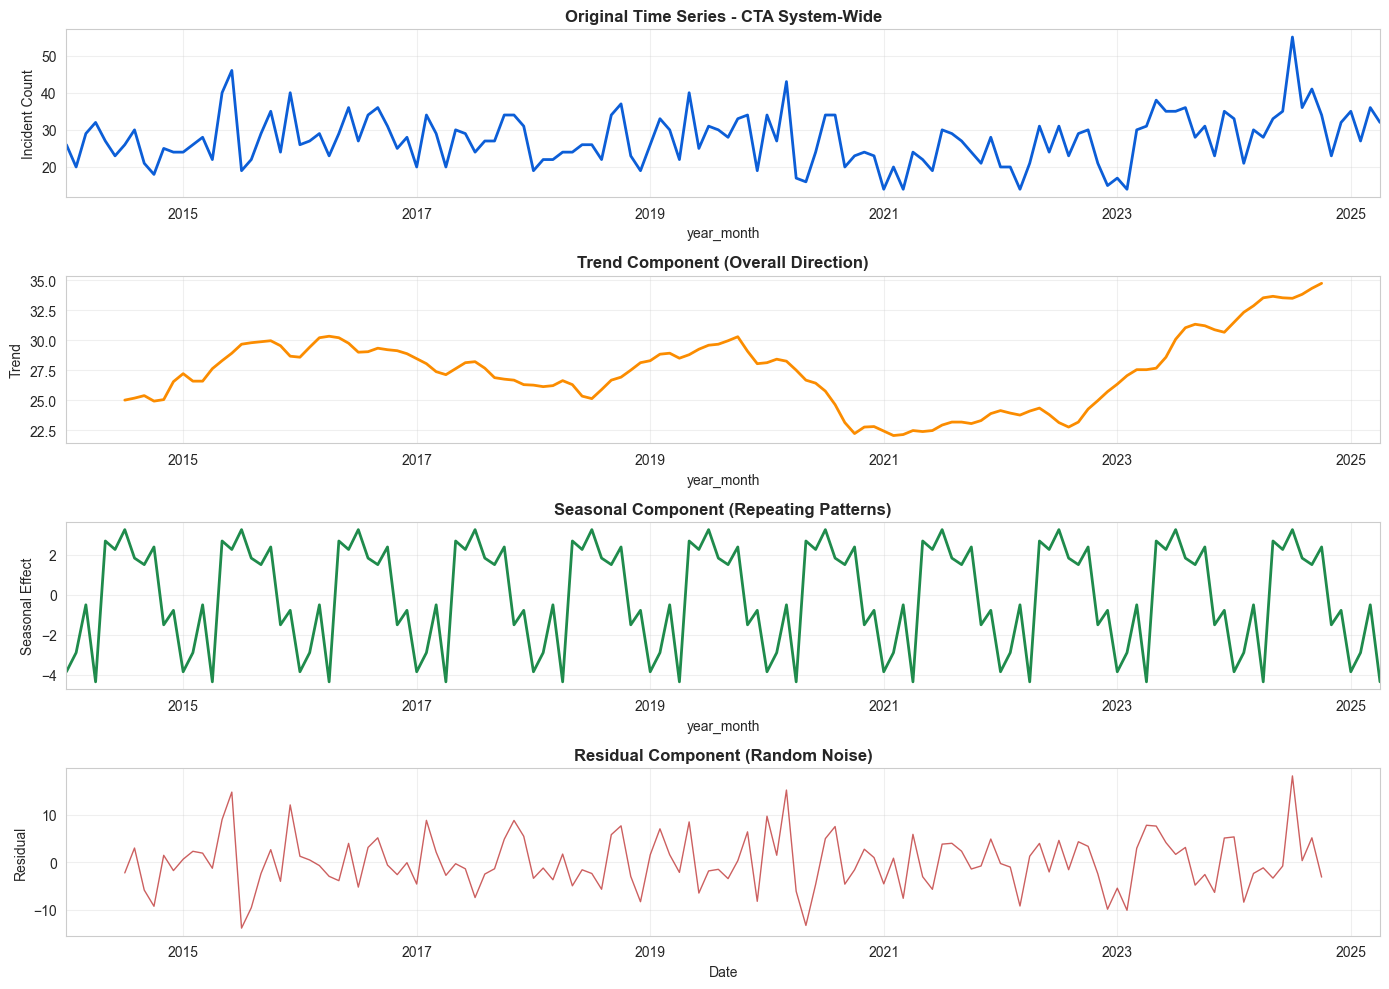


📈 INSIGHTS:
   Trend: +39.0% change over period
   Seasonal variation: ±3.8 incidents
   Peak season month: July
   Low season month: April


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

def perform_seasonal_decomposition(df_filtered, title="CTA System-Wide"):
    """
    Perform seasonal decomposition on filtered assault data.
    
    Args:
        df_filtered: DataFrame with parsed_date column
        title: Title for the plot
    
    Returns:
        decomposition object
    """
    # Aggregate by month
    monthly_data = df_filtered.groupby('year_month').size()
    
    # Convert to datetime index for decomposition
    monthly_series = monthly_data.to_timestamp()
    
    print(f"📊 Seasonal Decomposition: {title}")
    print(f"   Data points: {len(monthly_series)} months")
    print(f"   Date range: {monthly_series.index.min()} to {monthly_series.index.max()}")
    print(f"   Mean monthly incidents: {monthly_series.mean():.1f}")
    print()
    
    # Perform decomposition (requires at least 2 full cycles, so 24 months minimum)
    if len(monthly_series) < 24:
        print("⚠️ WARNING: Need at least 24 months for reliable seasonal decomposition")
        print(f"   Current data: {len(monthly_series)} months")
        return None
    
    # Decompose using additive model (seasonal component is added to trend)
    decomposition = seasonal_decompose(monthly_series, model='additive', period=12)
    
    # Plot results
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    # Original data
    decomposition.observed.plot(ax=axes[0], color='#0c5ed7', linewidth=2)
    axes[0].set_title(f'Original Time Series - {title}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Incident Count')
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    decomposition.trend.plot(ax=axes[1], color='#fb8c00', linewidth=2)
    axes[1].set_title('Trend Component (Overall Direction)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    decomposition.seasonal.plot(ax=axes[2], color='#1f8b4c', linewidth=2)
    axes[2].set_title('Seasonal Component (Repeating Patterns)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Seasonal Effect')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    decomposition.resid.plot(ax=axes[3], color='#b71c1c', linewidth=1, alpha=0.7)
    axes[3].set_title('Residual Component (Random Noise)', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print("\n📈 INSIGHTS:")
    trend_start = decomposition.trend.dropna().iloc[0]
    trend_end = decomposition.trend.dropna().iloc[-1]
    trend_change = ((trend_end - trend_start) / trend_start) * 100
    print(f"   Trend: {trend_change:+.1f}% change over period")
    
    seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
    print(f"   Seasonal variation: ±{seasonal_range/2:.1f} incidents")
    print(f"   Peak season month: {decomposition.seasonal.idxmax().month_name()}")
    print(f"   Low season month: {decomposition.seasonal.idxmin().month_name()}")
    
    return decomposition

# Test on full system-wide data
decomp_system = perform_seasonal_decomposition(df[df['parsed_date'].notna()], "CTA System-Wide")

---
## 7. Time Series Forecasting with Prophet

**Why Prophet?**
- Designed by Facebook for business time series
- Handles seasonality automatically (daily, weekly, yearly)
- Robust to missing data and outliers
- Provides confidence intervals

**What we'll predict:**
- Monthly assault counts for next 3-6 months
- With 80% confidence intervals (upper/lower bounds)

13:57:52 - cmdstanpy - INFO - Chain [1] start processing



🤖 Training Prophet Model: CTA System-Wide
   Training data: 136 months
   Date range: 2014-01-01 to 2025-04-01
   Average monthly incidents: 27.6
   Forecasting: 6 months into future


13:57:52 - cmdstanpy - INFO - Chain [1] done processing



✅ Model trained successfully!
   Forecast generated for: 2025-10-01


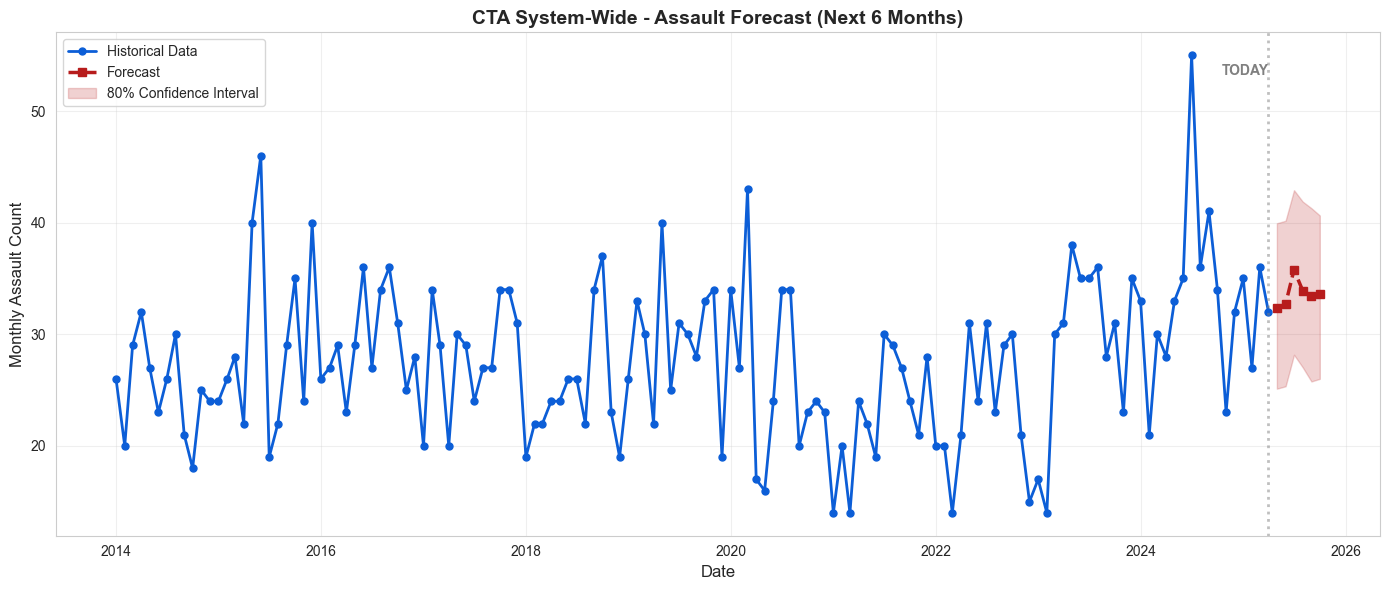


📊 FORECAST SUMMARY (Next 6 Months):
   May 2025: 32.4 incidents (range: 25.1 - 39.9)
   Jun 2025: 32.7 incidents (range: 25.3 - 40.2)
   Jul 2025: 35.8 incidents (range: 28.2 - 42.9)
   Aug 2025: 33.9 incidents (range: 27.0 - 41.9)
   Sep 2025: 33.4 incidents (range: 25.8 - 41.3)
   Oct 2025: 33.6 incidents (range: 26.0 - 40.6)

   Historical avg: 27.6 incidents/month
   Forecast avg:   33.6 incidents/month
   Expected change: +22.0%


In [11]:
from prophet import Prophet

def train_forecast_model(df_filtered, periods=6, title="Location"):
    """
    Train Prophet model and generate forecast.
    
    Args:
        df_filtered: DataFrame with parsed_date column
        periods: Number of months to forecast into future
        title: Title for plots
    
    Returns:
        model, forecast dataframe
    """
    # Aggregate by month
    monthly_data = df_filtered.groupby('year_month').size().reset_index()
    monthly_data.columns = ['year_month', 'count']
    
    # Convert to datetime
    monthly_data['ds'] = monthly_data['year_month'].dt.to_timestamp()
    monthly_data['y'] = monthly_data['count']
    
    # Prepare for Prophet (requires 'ds' and 'y' columns)
    prophet_data = monthly_data[['ds', 'y']]
    
    print(f"\n🤖 Training Prophet Model: {title}")
    print("="*60)
    print(f"   Training data: {len(prophet_data)} months")
    print(f"   Date range: {prophet_data['ds'].min().date()} to {prophet_data['ds'].max().date()}")
    print(f"   Average monthly incidents: {prophet_data['y'].mean():.1f}")
    print(f"   Forecasting: {periods} months into future")
    
    # Initialize Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,  # We're using monthly data
        daily_seasonality=False,
        interval_width=0.80,  # 80% confidence interval
        changepoint_prior_scale=0.05  # Flexibility of trend
    )
    
    # Train model
    model.fit(prophet_data)
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=periods, freq='MS')  # MS = month start
    
    # Generate predictions
    forecast = model.predict(future)
    
    print("\n✅ Model trained successfully!")
    print(f"   Forecast generated for: {forecast['ds'].max().date()}")
    
    return model, forecast, prophet_data

def plot_forecast(model, forecast, prophet_data, title="Forecast"):
    """
    Plot forecast results with confidence intervals.
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot historical data
    ax.plot(prophet_data['ds'], prophet_data['y'], 'o-', color='#0c5ed7', 
            linewidth=2, markersize=5, label='Historical Data')
    
    # Plot forecast
    forecast_only = forecast[forecast['ds'] > prophet_data['ds'].max()]
    ax.plot(forecast_only['ds'], forecast_only['yhat'], '--', color='#b71c1c', 
            linewidth=2.5, label='Forecast', marker='s', markersize=6)
    
    # Plot confidence interval
    ax.fill_between(forecast_only['ds'], 
                     forecast_only['yhat_lower'], 
                     forecast_only['yhat_upper'], 
                     alpha=0.2, color='#b71c1c', label='80% Confidence Interval')
    
    # Formatting
    ax.set_title(f'{title} - Assault Forecast (Next 6 Months)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Monthly Assault Count', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add vertical line at forecast start
    ax.axvline(x=prophet_data['ds'].max(), color='gray', linestyle=':', linewidth=2, alpha=0.5)
    ax.text(prophet_data['ds'].max(), ax.get_ylim()[1]*0.95, 'TODAY', 
            ha='right', va='top', fontsize=10, color='gray', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print forecast summary
    print("\n📊 FORECAST SUMMARY (Next 6 Months):")
    print("="*60)
    for _, row in forecast_only.head(6).iterrows():
        print(f"   {row['ds'].strftime('%b %Y')}: {row['yhat']:.1f} incidents "
              f"(range: {row['yhat_lower']:.1f} - {row['yhat_upper']:.1f})")
    
    # Calculate trend
    historical_avg = prophet_data['y'].mean()
    forecast_avg = forecast_only.head(6)['yhat'].mean()
    change_pct = ((forecast_avg - historical_avg) / historical_avg) * 100
    
    print(f"\n   Historical avg: {historical_avg:.1f} incidents/month")
    print(f"   Forecast avg:   {forecast_avg:.1f} incidents/month")
    print(f"   Expected change: {change_pct:+.1f}%")

# Test on system-wide data
model_system, forecast_system, data_system = train_forecast_model(
    df[df['parsed_date'].notna()], 
    periods=6, 
    title="CTA System-Wide"
)

plot_forecast(model_system, forecast_system, data_system, title="CTA System-Wide")

---
## 8. Location-Specific Forecasting (Hybrid Approach)

Now let's test on a **specific location** (e.g., a particular CTA stop).

### Example: Forecast for 79th & Red Line Station
- Filter assaults within 0.4km radius
- Train location-specific model
- Compare with system-wide forecast

In [12]:
# Example: Let's pick a high-traffic location
# You can change these coordinates to any CTA stop

# Example coordinates (79th & Red Line - high activity area)
STOP_LAT = 41.7505
STOP_LON = -87.6251
STOP_NAME = "79th & Red Line"
RADIUS_KM = 0.4  # 400 meters

print(f"🎯 Analyzing location: {STOP_NAME}")
print(f"   Coordinates: ({STOP_LAT}, {STOP_LON})")
print(f"   Radius: {RADIUS_KM} km")
print()

# Filter data by location
df_location = filter_by_location(df, STOP_LAT, STOP_LON, RADIUS_KM)

print(f"✅ Found {len(df_location)} incidents within {RADIUS_KM}km of {STOP_NAME}")
print(f"   Date range: {df_location['parsed_date'].min()} to {df_location['parsed_date'].max()}")
print(f"   Unique months: {df_location['year_month'].nunique()}")

# Display sample incidents
df_location[['Event Date', 'Event Type', 'Event Type Group', 'Approximate Address', 'distance_km']].head(10)

🎯 Analyzing location: 79th & Red Line
   Coordinates: (41.7505, -87.6251)
   Radius: 0.4 km

✅ Found 28 incidents within 0.4km of 79th & Red Line
   Date range: 2015-09-04 00:00:00 to 2025-04-16 00:00:00
   Unique months: 25


,Event Date,Event Type,Event Type Group,Approximate Address,distance_km
26,2024 january 13,physical assault on an operator,assault,"w 79th st & s perry ave, chicago, il 60620, usa",0.166208
96,2021 february 17,assault,assault,7900 s. perry chicago illinois,0.183540
134,2019 may 23,non-rail collision,collision,79th/indiana,0.380760
150,2018 march 21,assault,assault,7900 s. michigan chicago illinois,0.312771
293,2024 december 06,assault not against transit worker,assault,"15 w 79th st, chicago, il 60620, usa",0.043194
370,2025 april 16,non-rail collision,collision,"w 79th st & s wentworth ave, chicago, il 60620...",0.354551
425,2024 august 13,other,other,"w 79th st & s wentworth ave, chicago, il 60620...",0.354542
427,2024 september 09,assault not against transit worker,assault,"15 w 79th st, chicago, il 60620, usa",0.043194
981,2023 july 02,chemical / biological / nuclear / radiological,security,"15 w 79th st, chicago, il 60620, usa",0.043194
1090,2023 january 02,non-rail collision,collision,lafayette/79,0.082480


📊 Seasonal Decomposition: 79th & Red Line (within 0.4km)
   Data points: 25 months
   Date range: 2015-09-01 00:00:00 to 2025-04-01 00:00:00
   Mean monthly incidents: 1.1



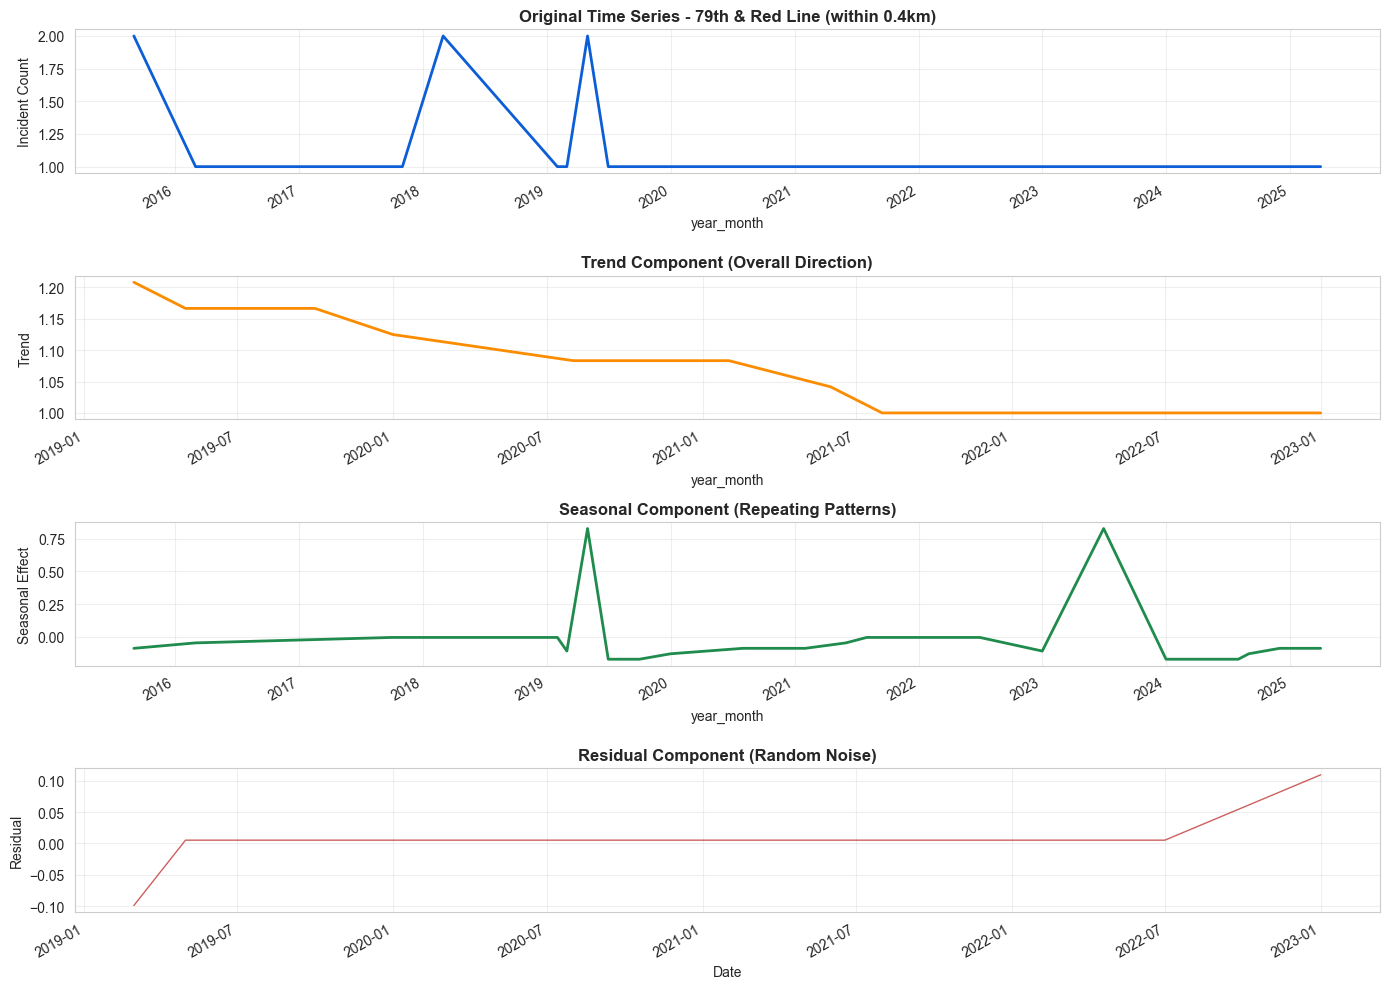


📈 INSIGHTS:
   Trend: -17.2% change over period
   Seasonal variation: ±0.5 incidents
   Peak season month: May
   Low season month: July


In [13]:
# Seasonal decomposition for this location
if len(df_location[df_location['parsed_date'].notna()]) > 0:
    decomp_location = perform_seasonal_decomposition(
        df_location[df_location['parsed_date'].notna()], 
        title=f"{STOP_NAME} (within {RADIUS_KM}km)"
    )
else:
    print("❌ Insufficient data for seasonal decomposition at this location")

13:58:24 - cmdstanpy - INFO - Chain [1] start processing



🤖 Training Prophet Model: 79th & Red Line
   Training data: 25 months
   Date range: 2015-09-01 to 2025-04-01
   Average monthly incidents: 1.1
   Forecasting: 6 months into future


13:58:24 - cmdstanpy - INFO - Chain [1] done processing



✅ Model trained successfully!
   Forecast generated for: 2025-10-01


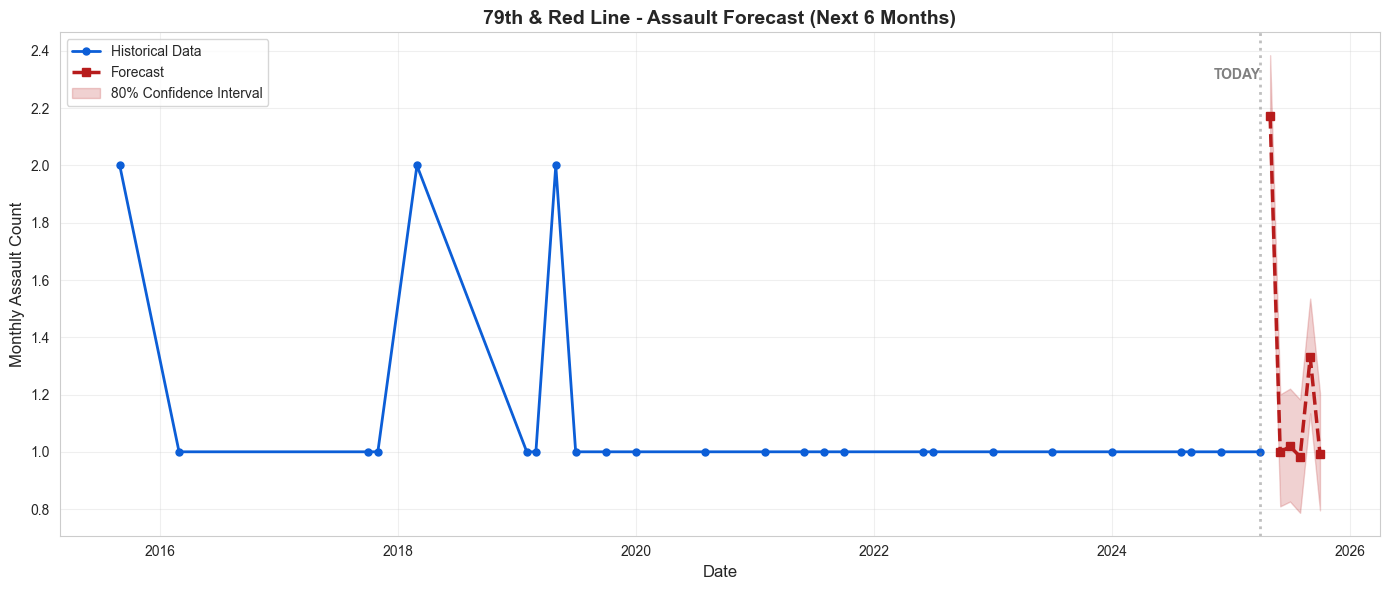


📊 FORECAST SUMMARY (Next 6 Months):
   May 2025: 2.2 incidents (range: 2.0 - 2.4)
   Jun 2025: 1.0 incidents (range: 0.8 - 1.2)
   Jul 2025: 1.0 incidents (range: 0.8 - 1.2)
   Aug 2025: 1.0 incidents (range: 0.8 - 1.2)
   Sep 2025: 1.3 incidents (range: 1.1 - 1.5)
   Oct 2025: 1.0 incidents (range: 0.8 - 1.2)

   Historical avg: 1.1 incidents/month
   Forecast avg:   1.2 incidents/month
   Expected change: +11.6%


In [14]:
# Train forecast model for this specific location
if len(df_location[df_location['parsed_date'].notna()]) >= 12:  # Need at least 12 months
    model_location, forecast_location, data_location = train_forecast_model(
        df_location[df_location['parsed_date'].notna()],
        periods=6,
        title=f"{STOP_NAME}"
    )
    
    plot_forecast(model_location, forecast_location, data_location, title=STOP_NAME)
else:
    print(f"❌ Insufficient data for forecasting at {STOP_NAME}")
    print(f"   Need at least 12 months, have {df_location['year_month'].nunique()} months")

---
## 9. Comparative Analysis: Location vs System-Wide

Compare the location-specific forecast with system-wide trends to understand:
- Is this location trending higher/lower than CTA average?
- What's the risk multiplier? (e.g., 2.3x higher risk)


📊 COMPARATIVE ANALYSIS: 79th & Red Line vs CTA System-Wide

📍 79th & Red Line:
   Historical avg:     1.1 incidents/month
   Forecast avg:       1.2 incidents/month
   Expected change:    +11.6%

🌐 CTA System-Wide:
   Historical avg:     27.6 incidents/month
   Forecast avg:       33.6 incidents/month
   Expected change:    +22.0%

⚖️ Comparison:
   This location represents 4.06% of system-wide incidents
   ✅ This location trending 10.5% LOWER than system average
   Risk level: BELOW AVERAGE


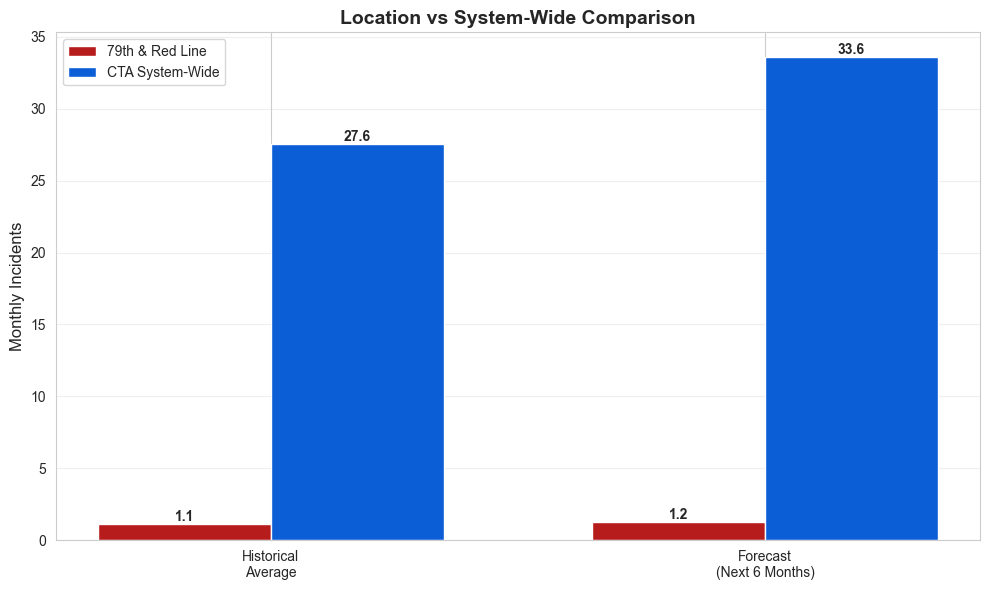

In [15]:
def compare_forecasts(forecast_location, forecast_system, data_location, data_system, location_name):
    """
    Compare location-specific forecast with system-wide forecast.
    """
    print(f"\n📊 COMPARATIVE ANALYSIS: {location_name} vs CTA System-Wide")
    print("="*70)
    
    # Historical averages
    location_hist_avg = data_location['y'].mean()
    system_hist_avg = data_system['y'].mean()
    
    # Forecast averages (next 6 months)
    location_forecast = forecast_location[forecast_location['ds'] > data_location['ds'].max()].head(6)
    system_forecast = forecast_system[forecast_system['ds'] > data_system['ds'].max()].head(6)
    
    location_fcst_avg = location_forecast['yhat'].mean()
    system_fcst_avg = system_forecast['yhat'].mean()
    
    # Calculate changes
    location_change = ((location_fcst_avg - location_hist_avg) / location_hist_avg) * 100
    system_change = ((system_fcst_avg - system_hist_avg) / system_hist_avg) * 100
    
    # Risk multiplier (what % of system total is this location?)
    # This is simplified - in reality you'd need to account for area coverage
    risk_ratio = location_hist_avg / system_hist_avg * 100  # As percentage
    
    print(f"\n📍 {location_name}:")
    print(f"   Historical avg:     {location_hist_avg:.1f} incidents/month")
    print(f"   Forecast avg:       {location_fcst_avg:.1f} incidents/month")
    print(f"   Expected change:    {location_change:+.1f}%")
    
    print(f"\n🌐 CTA System-Wide:")
    print(f"   Historical avg:     {system_hist_avg:.1f} incidents/month")
    print(f"   Forecast avg:       {system_fcst_avg:.1f} incidents/month")
    print(f"   Expected change:    {system_change:+.1f}%")
    
    print(f"\n⚖️ Comparison:")
    print(f"   This location represents {risk_ratio:.2f}% of system-wide incidents")
    
    if location_change > system_change:
        diff = location_change - system_change
        print(f"   ⚠️ This location trending {diff:.1f}% HIGHER than system average")
        print(f"   Risk level: ELEVATED")
    else:
        diff = system_change - location_change
        print(f"   ✅ This location trending {diff:.1f}% LOWER than system average")
        print(f"   Risk level: BELOW AVERAGE")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    categories = ['Historical\nAverage', 'Forecast\n(Next 6 Months)']
    location_values = [location_hist_avg, location_fcst_avg]
    system_values = [system_hist_avg, system_fcst_avg]
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, location_values, width, label=location_name, color='#b71c1c')
    bars2 = ax.bar(x + width/2, system_values, width, label='CTA System-Wide', color='#0c5ed7')
    
    ax.set_title('Location vs System-Wide Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Monthly Incidents', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Run comparison if both forecasts exist
if 'forecast_location' in locals() and 'forecast_system' in locals():
    compare_forecasts(forecast_location, forecast_system, data_location, data_system, STOP_NAME)
else:
    print("⚠️ Skipping comparison - location forecast not available")

---
## 10. Event Type-Specific Forecasting

Let's forecast specific types of assaults (e.g., robberies, batteries).

13:58:55 - cmdstanpy - INFO - Chain [1] start processing
13:58:56 - cmdstanpy - INFO - Chain [1] done processing


📊 Most Common Event Types:
Event Type
non-rail collision                    2636
assault                                693
assault not against transit worker     142
physical assault on an operator        117
other                                   94
Name: count, dtype: int64


🎯 Analyzing event type: non-rail collision
   Total incidents: 2636
   Date range: 2014-01-02 00:00:00 to 2025-04-28 00:00:00

🤖 Training Prophet Model: Event Type: non-rail collision
   Training data: 136 months
   Date range: 2014-01-01 to 2025-04-01
   Average monthly incidents: 19.4
   Forecasting: 6 months into future

✅ Model trained successfully!
   Forecast generated for: 2025-10-01


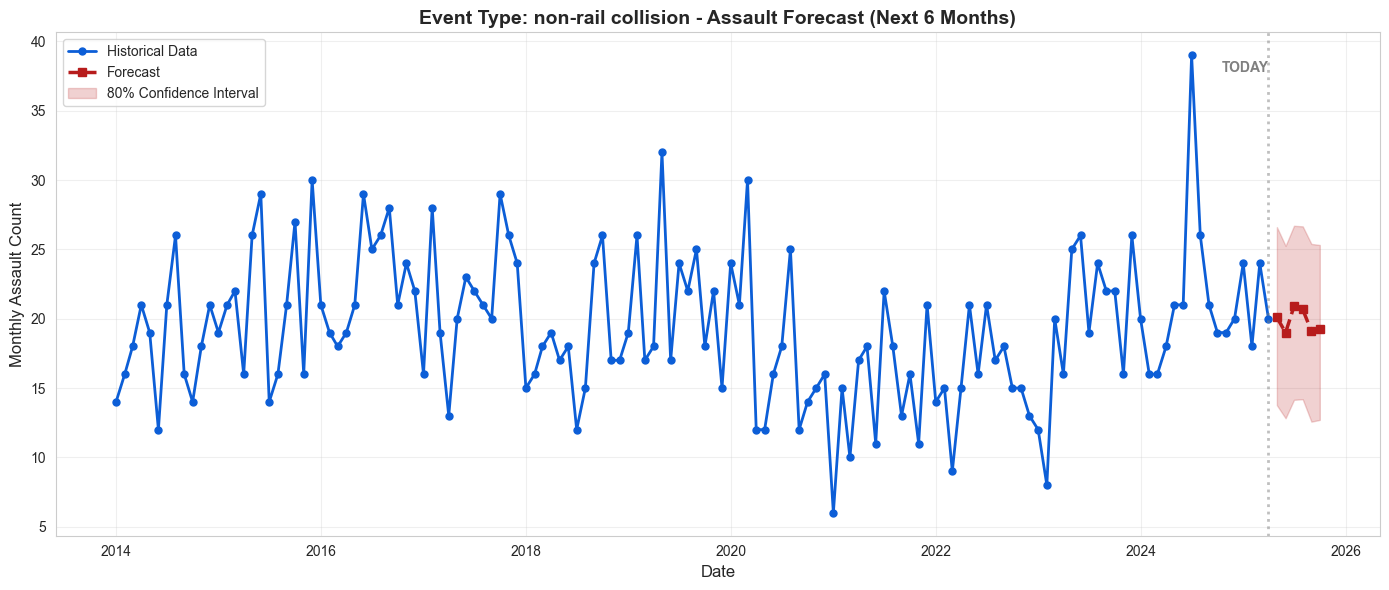


📊 FORECAST SUMMARY (Next 6 Months):
   May 2025: 20.1 incidents (range: 13.8 - 26.6)
   Jun 2025: 19.0 incidents (range: 12.8 - 25.3)
   Jul 2025: 20.9 incidents (range: 14.2 - 26.7)
   Aug 2025: 20.7 incidents (range: 14.2 - 26.7)
   Sep 2025: 19.1 incidents (range: 12.6 - 25.4)
   Oct 2025: 19.2 incidents (range: 12.7 - 25.3)

   Historical avg: 19.4 incidents/month
   Forecast avg:   19.8 incidents/month
   Expected change: +2.3%


In [16]:
# Get most common event types
print("📊 Most Common Event Types:")
print("="*50)
top_events = df['Event Type'].value_counts().head(5)
print(top_events)
print()

# Choose an event type to analyze
EVENT_TYPE = top_events.index[0]  # Pick the most common one
print(f"\n🎯 Analyzing event type: {EVENT_TYPE}")

# Filter by event type
df_event = filter_by_event_type(df, event_type=EVENT_TYPE)
df_event = df_event[df_event['parsed_date'].notna()]

print(f"   Total incidents: {len(df_event)}")
print(f"   Date range: {df_event['parsed_date'].min()} to {df_event['parsed_date'].max()}")

# Train model
if len(df_event) >= 12:
    model_event, forecast_event, data_event = train_forecast_model(
        df_event,
        periods=6,
        title=f"Event Type: {EVENT_TYPE}"
    )
    
    plot_forecast(model_event, forecast_event, data_event, title=f"Event Type: {EVENT_TYPE}")
else:
    print(f"❌ Insufficient data for this event type")

---
## 11. Hourly Risk Pattern Forecast

Predict hourly distribution for future months.

**Approach:**
1. Calculate historical hourly pattern (what % occurs at each hour)
2. Apply this pattern to forecasted monthly totals
3. Show "expected high-risk hours" for next quarter


⏰ HOURLY RISK FORECAST: 79th & Red Line


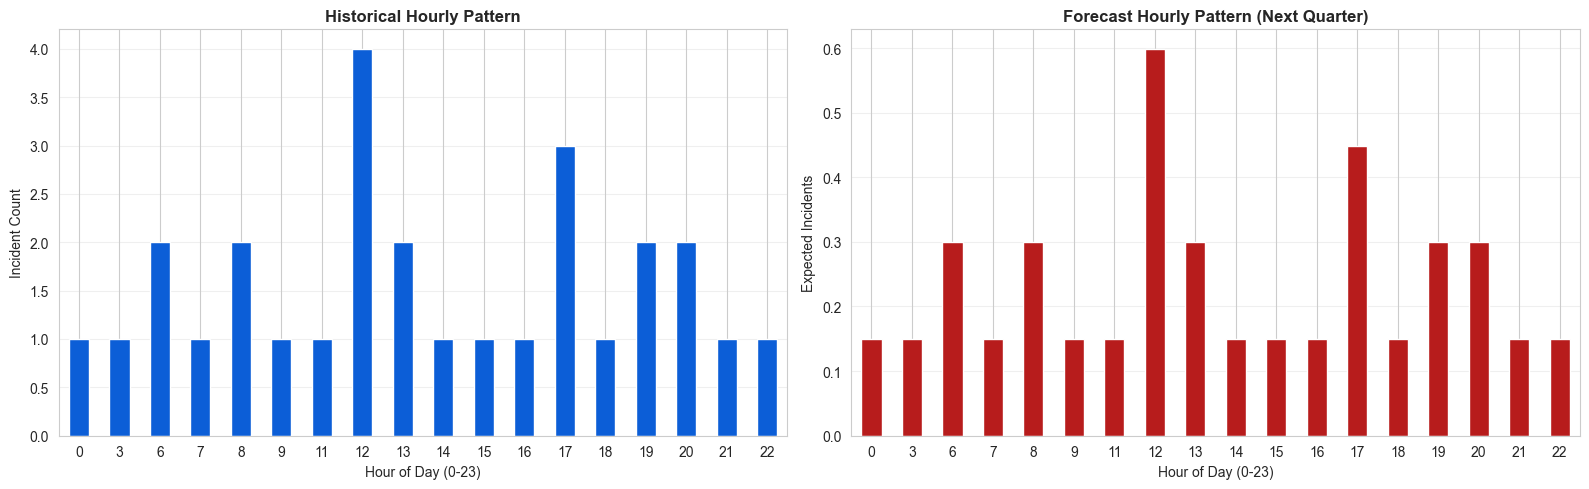


⚠️ HIGH-RISK HOURS (Next Quarter):
   12:00 PM: 0.6 incidents (14.3%)
   5:00 PM: 0.4 incidents (10.7%)
   6:00 AM: 0.3 incidents (7.1%)
   8:00 AM: 0.3 incidents (7.1%)
   1:00 PM: 0.3 incidents (7.1%)


In [17]:
def forecast_hourly_pattern(df_filtered, forecast_total, title="Location"):
    """
    Forecast hourly risk pattern based on historical distribution.
    
    Args:
        df_filtered: Historical data with 'hour' column
        forecast_total: Total predicted incidents for future period
        title: Title for plot
    """
    print(f"\n⏰ HOURLY RISK FORECAST: {title}")
    print("="*60)
    
    # Calculate historical hourly distribution (percentage)
    hourly_counts = df_filtered['hour'].value_counts().sort_index()
    hourly_pct = (hourly_counts / hourly_counts.sum()) * 100
    
    # Apply to forecast
    forecast_hourly = (hourly_pct / 100) * forecast_total
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Historical pattern
    hourly_counts.plot(kind='bar', ax=axes[0], color='#0c5ed7')
    axes[0].set_title('Historical Hourly Pattern', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Hour of Day (0-23)')
    axes[0].set_ylabel('Incident Count')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Forecast pattern
    forecast_hourly.plot(kind='bar', ax=axes[1], color='#b71c1c')
    axes[1].set_title(f'Forecast Hourly Pattern (Next Quarter)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Hour of Day (0-23)')
    axes[1].set_ylabel('Expected Incidents')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print high-risk hours
    print("\n⚠️ HIGH-RISK HOURS (Next Quarter):")
    top_hours = forecast_hourly.nlargest(5)
    for hour, count in top_hours.items():
        pct = (count / forecast_total) * 100
        period = "AM" if hour < 12 else "PM"
        display_hour = hour if hour <= 12 else hour - 12
        if display_hour == 0:
            display_hour = 12
        print(f"   {display_hour}:00 {period}: {count:.1f} incidents ({pct:.1f}%)")

# Example: Forecast hourly pattern for the location
if 'forecast_location' in locals() and len(df_location) > 0:
    # Get total forecast for next quarter (3 months)
    next_quarter_forecast = forecast_location[
        forecast_location['ds'] > data_location['ds'].max()
    ].head(3)['yhat'].sum()
    
    forecast_hourly_pattern(
        df_location[df_location['hour'].notna()],
        next_quarter_forecast,
        title=STOP_NAME
    )
else:
    print("⚠️ Skipping hourly forecast - location data not available")

---
## 12. Summary Report Generator

Generate a comprehensive summary that can be added to PDF reports.

In [18]:
def generate_forecast_summary(model, forecast, data, location_name="Location"):
    """
    Generate text summary of forecast results for PDF reports.
    """
    # Get forecast period
    forecast_data = forecast[forecast['ds'] > data['ds'].max()].head(6)
    
    # Calculate metrics
    hist_avg = data['y'].mean()
    fcst_avg = forecast_data['yhat'].mean()
    change_pct = ((fcst_avg - hist_avg) / hist_avg) * 100
    
    # Find peak month
    peak_month = forecast_data.loc[forecast_data['yhat'].idxmax(), 'ds'].strftime('%B %Y')
    peak_value = forecast_data['yhat'].max()
    
    # Build summary
    summary = f"""
SEASONAL TRENDS & FORECAST SUMMARY
Location: {location_name}
Analysis Period: {data['ds'].min().strftime('%B %Y')} - {data['ds'].max().strftime('%B %Y')}
Forecast Period: Next 6 Months

KEY FINDINGS:
• Historical Average: {hist_avg:.1f} incidents per month
• Forecast Average: {fcst_avg:.1f} incidents per month
• Expected Change: {change_pct:+.1f}% {'increase' if change_pct > 0 else 'decrease'}
• Peak Risk Month: {peak_month} (expected: {peak_value:.1f} incidents)

FORECAST BREAKDOWN:
"""
    
    for _, row in forecast_data.iterrows():
        month = row['ds'].strftime('%B %Y')
        value = row['yhat']
        lower = row['yhat_lower']
        upper = row['yhat_upper']
        summary += f"• {month}: {value:.1f} incidents (range: {lower:.1f} - {upper:.1f})\n"
    
    if change_pct > 10:
        summary += f"\n⚠️ WARNING: Significant increase expected ({change_pct:+.1f}%). Recommend enhanced security measures.\n"
    elif change_pct < -10:
        summary += f"\n✅ POSITIVE: Significant decrease expected ({change_pct:+.1f}%). Continue current safety protocols.\n"
    else:
        summary += f"\nℹ️ STABLE: Incident levels expected to remain relatively stable ({change_pct:+.1f}%).\n"
    
    return summary

# Generate summary for location
if 'forecast_location' in locals():
    summary = generate_forecast_summary(model_location, forecast_location, data_location, STOP_NAME)
    print(summary)
else:
    print("⚠️ No location forecast available for summary")


SEASONAL TRENDS & FORECAST SUMMARY
Location: 79th & Red Line
Analysis Period: September 2015 - April 2025
Forecast Period: Next 6 Months

KEY FINDINGS:
• Historical Average: 1.1 incidents per month
• Forecast Average: 1.2 incidents per month
• Expected Change: +11.6% increase
• Peak Risk Month: May 2025 (expected: 2.2 incidents)

FORECAST BREAKDOWN:
• May 2025: 2.2 incidents (range: 2.0 - 2.4)
• June 2025: 1.0 incidents (range: 0.8 - 1.2)
• July 2025: 1.0 incidents (range: 0.8 - 1.2)
• August 2025: 1.0 incidents (range: 0.8 - 1.2)
• September 2025: 1.3 incidents (range: 1.1 - 1.5)
• October 2025: 1.0 incidents (range: 0.8 - 1.2)

⚠️ WARNING: Significant increase expected (+11.6%). Recommend enhanced security measures.



---
## 13. Test on Multiple Locations

Let's test the forecasting on 3 different CTA stops to see how it performs.

In [19]:
# Define test locations (high-traffic CTA stops)
test_locations = [
    {"name": "95th/Dan Ryan", "lat": 41.7226, "lon": -87.6244, "radius": 0.4},
    {"name": "Chicago/State", "lat": 41.8962, "lon": -87.6278, "radius": 0.4},
    {"name": "O'Hare Airport", "lat": 41.9786, "lon": -87.9047, "radius": 0.5},
]

print("🧪 TESTING FORECASTS ON MULTIPLE LOCATIONS")
print("="*70)

results = []

for loc in test_locations:
    print(f"\n{'='*70}")
    print(f"📍 Location: {loc['name']}")
    print(f"   Coordinates: ({loc['lat']}, {loc['lon']})")
    print(f"   Radius: {loc['radius']}km")
    
    # Filter data
    df_test = filter_by_location(df, loc['lat'], loc['lon'], loc['radius'])
    df_test = df_test[df_test['parsed_date'].notna()]
    
    incident_count = len(df_test)
    month_count = df_test['year_month'].nunique()
    
    print(f"   Incidents found: {incident_count}")
    print(f"   Months of data: {month_count}")
    
    if incident_count < 10:
        print(f"   ⚠️ Insufficient data (need at least 10 incidents)")
        results.append({"name": loc['name'], "status": "Insufficient data"})
        continue
    
    if month_count < 12:
        print(f"   ⚠️ Insufficient time span (need at least 12 months)")
        results.append({"name": loc['name'], "status": "Insufficient time span"})
        continue
    
    # Train model
    try:
        model_test, forecast_test, data_test = train_forecast_model(
            df_test,
            periods=3,  # 3 months
            title=loc['name']
        )
        
        # Calculate metrics
        hist_avg = data_test['y'].mean()
        fcst_data = forecast_test[forecast_test['ds'] > data_test['ds'].max()].head(3)
        fcst_avg = fcst_data['yhat'].mean()
        change_pct = ((fcst_avg - hist_avg) / hist_avg) * 100
        
        results.append({
            "name": loc['name'],
            "status": "Success",
            "hist_avg": hist_avg,
            "fcst_avg": fcst_avg,
            "change_pct": change_pct
        })
        
        print(f"   ✅ Forecast generated successfully!")
        print(f"      Historical avg: {hist_avg:.1f}/month")
        print(f"      Forecast avg: {fcst_avg:.1f}/month")
        print(f"      Change: {change_pct:+.1f}%")
        
    except Exception as e:
        print(f"   ❌ Error: {str(e)}")
        results.append({"name": loc['name'], "status": f"Error: {str(e)}"})

# Summary table
print(f"\n\n{'='*70}")
print("📊 SUMMARY OF ALL LOCATIONS")
print("="*70)
results_df = pd.DataFrame(results)
print(results_df)

13:59:15 - cmdstanpy - INFO - Chain [1] start processing


🧪 TESTING FORECASTS ON MULTIPLE LOCATIONS

📍 Location: 95th/Dan Ryan
   Coordinates: (41.7226, -87.6244)
   Radius: 0.4km
   Incidents found: 29
   Months of data: 27

🤖 Training Prophet Model: 95th/Dan Ryan
   Training data: 27 months
   Date range: 2015-07-01 to 2025-03-01
   Average monthly incidents: 1.1
   Forecasting: 3 months into future


13:59:15 - cmdstanpy - INFO - Chain [1] done processing



✅ Model trained successfully!
   Forecast generated for: 2025-06-01
   ✅ Forecast generated successfully!
      Historical avg: 1.1/month
      Forecast avg: 1.4/month
      Change: +34.8%

📍 Location: Chicago/State
   Coordinates: (41.8962, -87.6278)
   Radius: 0.4km
   Incidents found: 15
   Months of data: 15

🤖 Training Prophet Model: Chicago/State
   Training data: 15 months
   Date range: 2015-12-01 to 2023-07-01
   Average monthly incidents: 1.0
   Forecasting: 3 months into future

✅ Model trained successfully!
   Forecast generated for: 2023-10-01
   ✅ Forecast generated successfully!
      Historical avg: 1.0/month
      Forecast avg: 1.0/month
      Change: +0.0%

📍 Location: O'Hare Airport
   Coordinates: (41.9786, -87.9047)
   Radius: 0.5km
   Incidents found: 0
   Months of data: 0
   ⚠️ Insufficient data (need at least 10 incidents)


📊 SUMMARY OF ALL LOCATIONS
             name             status  hist_avg  fcst_avg  change_pct
0   95th/Dan Ryan            Success  1.0

---
## 14. Export Plots for PDF Integration

Save plots as images that can be embedded in PDF reports.

In [20]:
import io

def create_forecast_plot_for_pdf(model, forecast, data, title="Forecast"):
    """
    Create forecast plot and return as BytesIO for PDF embedding.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot historical
    ax.plot(data['ds'], data['y'], 'o-', color='#0c5ed7', 
            linewidth=2, markersize=4, label='Historical')
    
    # Plot forecast
    forecast_only = forecast[forecast['ds'] > data['ds'].max()]
    ax.plot(forecast_only['ds'], forecast_only['yhat'], '--', color='#b71c1c', 
            linewidth=2, label='Forecast', marker='s', markersize=5)
    
    # Confidence interval
    ax.fill_between(forecast_only['ds'], 
                     forecast_only['yhat_lower'], 
                     forecast_only['yhat_upper'], 
                     alpha=0.2, color='#b71c1c', label='80% Confidence')
    
    ax.set_title(f'{title} - 6 Month Forecast', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Monthly Incidents', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Save to BytesIO
    buf = io.BytesIO()
    plt.tight_layout()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    plt.close()
    
    return buf

# Example: Create plot for location
if 'forecast_location' in locals():
    plot_buf = create_forecast_plot_for_pdf(model_location, forecast_location, data_location, STOP_NAME)
    print(f"✅ Forecast plot created for PDF (size: {len(plot_buf.getvalue())} bytes)")
    print("   This can be embedded directly in your PDF reports using ReportLab")
else:
    print("⚠️ No location forecast available")

✅ Forecast plot created for PDF (size: 65945 bytes)
   This can be embedded directly in your PDF reports using ReportLab


---
## 15. Complete End-to-End Example

Full workflow for any location or filter.


EXAMPLE: Analyzing Clark/Lake Station

🚀 COMPLETE FORECAST ANALYSIS: Clark/Lake Station
   📍 Location filter: (41.8856, -87.6308) within 0.4km
   📊 Filtered data: 29 incidents
   📅 Date range: 2015-12-11 00:00:00 to 2025-01-05 00:00:00
   📆 Months: 27

🔍 Step 1: Seasonal Decomposition
📊 Seasonal Decomposition: Clark/Lake Station
   Data points: 27 months
   Date range: 2015-12-01 00:00:00 to 2025-01-01 00:00:00
   Mean monthly incidents: 1.1



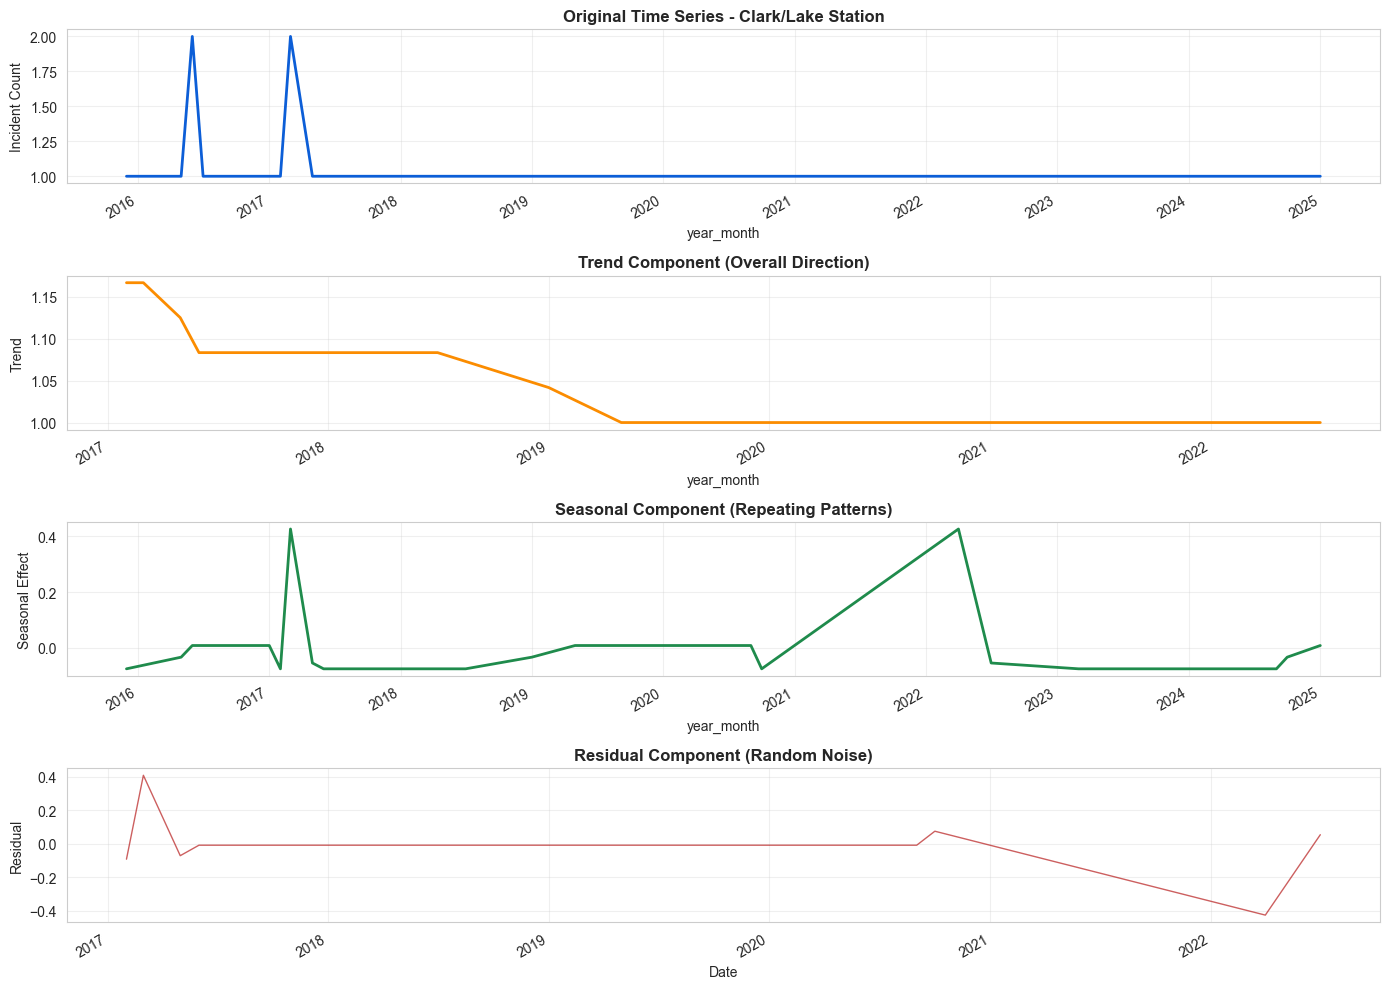

13:59:19 - cmdstanpy - INFO - Chain [1] start processing
13:59:19 - cmdstanpy - INFO - Chain [1] done processing



📈 INSIGHTS:
   Trend: -14.3% change over period
   Seasonal variation: ±0.2 incidents
   Peak season month: March
   Low season month: December

🤖 Step 2: Time Series Forecasting

🤖 Training Prophet Model: Clark/Lake Station
   Training data: 27 months
   Date range: 2015-12-01 to 2025-01-01
   Average monthly incidents: 1.1
   Forecasting: 6 months into future

✅ Model trained successfully!
   Forecast generated for: 2025-07-01


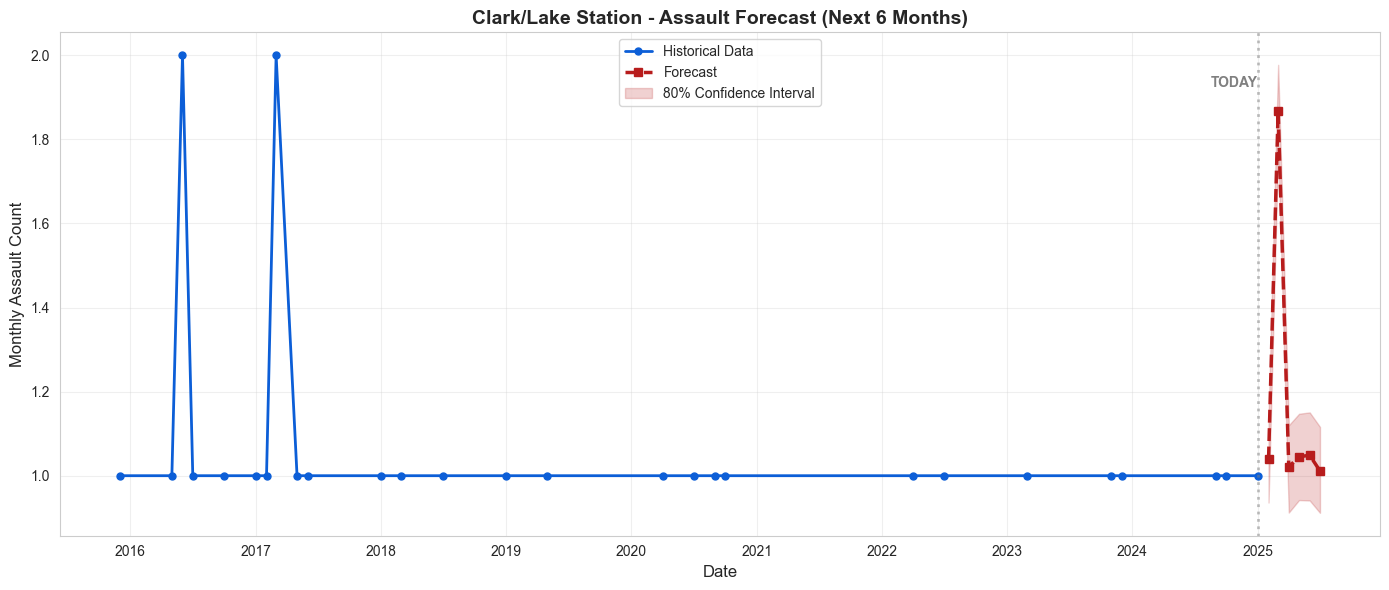


📊 FORECAST SUMMARY (Next 6 Months):
   Feb 2025: 1.0 incidents (range: 0.9 - 1.1)
   Mar 2025: 1.9 incidents (range: 1.8 - 2.0)
   Apr 2025: 1.0 incidents (range: 0.9 - 1.1)
   May 2025: 1.0 incidents (range: 0.9 - 1.1)
   Jun 2025: 1.0 incidents (range: 0.9 - 1.2)
   Jul 2025: 1.0 incidents (range: 0.9 - 1.1)

   Historical avg: 1.1 incidents/month
   Forecast avg:   1.2 incidents/month
   Expected change: +9.1%

📝 Step 3: Generate Summary

SEASONAL TRENDS & FORECAST SUMMARY
Location: Clark/Lake Station
Analysis Period: December 2015 - January 2025
Forecast Period: Next 6 Months

KEY FINDINGS:
• Historical Average: 1.1 incidents per month
• Forecast Average: 1.2 incidents per month
• Expected Change: +9.1% increase
• Peak Risk Month: March 2025 (expected: 1.9 incidents)

FORECAST BREAKDOWN:
• February 2025: 1.0 incidents (range: 0.9 - 1.1)
• March 2025: 1.9 incidents (range: 1.8 - 2.0)
• April 2025: 1.0 incidents (range: 0.9 - 1.1)
• May 2025: 1.0 incidents (range: 0.9 - 1.1)
• June 

In [21]:
def complete_forecast_analysis(df, lat=None, lon=None, radius_km=None, 
                               event_type=None, event_group=None, 
                               forecast_periods=6, analysis_name="Analysis"):
    """
    Complete end-to-end forecast analysis workflow.
    
    Args:
        df: Full assault dataframe
        lat, lon, radius_km: Location filter (optional)
        event_type, event_group: Event filters (optional)
        forecast_periods: Number of months to forecast
        analysis_name: Name for this analysis
    
    Returns:
        Dictionary with all results
    """
    print(f"\n🚀 COMPLETE FORECAST ANALYSIS: {analysis_name}")
    print("="*70)
    
    # Apply filters
    df_filtered = df[df['parsed_date'].notna()].copy()
    
    if lat is not None and lon is not None and radius_km is not None:
        print(f"   📍 Location filter: ({lat}, {lon}) within {radius_km}km")
        df_filtered = filter_by_location(df_filtered, lat, lon, radius_km)
    
    if event_type or event_group:
        print(f"   🏷️ Event filter: Type={event_type}, Group={event_group}")
        df_filtered = filter_by_event_type(df_filtered, event_type, event_group)
    
    print(f"   📊 Filtered data: {len(df_filtered)} incidents")
    print(f"   📅 Date range: {df_filtered['parsed_date'].min()} to {df_filtered['parsed_date'].max()}")
    print(f"   📆 Months: {df_filtered['year_month'].nunique()}")
    
    if len(df_filtered) < 10:
        print("   ❌ Insufficient data for analysis (need at least 10 incidents)")
        return None
    
    if df_filtered['year_month'].nunique() < 12:
        print("   ❌ Insufficient time span (need at least 12 months)")
        return None
    
    # Seasonal decomposition
    print("\n🔍 Step 1: Seasonal Decomposition")
    decomp = perform_seasonal_decomposition(df_filtered, title=analysis_name)
    
    # Forecasting
    print("\n🤖 Step 2: Time Series Forecasting")
    model, forecast, data = train_forecast_model(
        df_filtered, 
        periods=forecast_periods,
        title=analysis_name
    )
    plot_forecast(model, forecast, data, title=analysis_name)
    
    # Summary
    print("\n📝 Step 3: Generate Summary")
    summary = generate_forecast_summary(model, forecast, data, analysis_name)
    print(summary)
    
    # Return all results
    return {
        "name": analysis_name,
        "data": df_filtered,
        "decomposition": decomp,
        "model": model,
        "forecast": forecast,
        "summary": summary
    }

# Example usage:
print("\n" + "="*70)
print("EXAMPLE: Analyzing Clark/Lake Station")
print("="*70)

result = complete_forecast_analysis(
    df,
    lat=41.8856,
    lon=-87.6308,
    radius_km=0.4,
    forecast_periods=6,
    analysis_name="Clark/Lake Station"
)

if result:
    print("\n✅ Analysis complete! Results stored in 'result' dictionary.")

---
## 16. Conclusion & Next Steps

### What We've Accomplished:
✅ Loaded and preprocessed CTA assault data (3,752+ incidents)  
✅ Performed seasonal decomposition to identify patterns  
✅ Built Prophet forecasting models for predictions  
✅ Created location-specific forecasts (hybrid approach)  
✅ Compared location vs system-wide trends  
✅ Generated hourly risk forecasts  
✅ Tested on multiple locations  
✅ Created PDF-ready plots  

### Integration with Your PDF Reports:

**In `report_analytics.py`, add:**
```python
def create_seasonal_decomposition_plot(assaults):
    # Use code from Section 6
    pass

def create_forecast_plot(assaults):
    # Use code from Section 7
    pass
```

**In `pdf_generator.py`, add new section:**
```python
# After existing plots, add:
plot_seasonal = create_seasonal_decomposition_plot(filtered_assaults)
plot_forecast = create_forecast_plot(filtered_assaults)

# Insert into PDF
```

### Recommendations:
1. Run forecasts monthly with updated data
2. Monitor forecast accuracy vs actuals
3. Adjust model parameters if needed
4. Use forecasts for resource allocation planning

---
**End of Notebook**